# CausalMan: Generating Synthetic Causal Data

This notebook demonstrates how to use the `CausalMan` class to generate synthetic data with a known causal structure. The workflow is explained step by step, with a focus on clarity and reproducibility.

---


## 1. Setup and Imports

First, we import the necessary libraries and the `CausalMan` class. This class is the main entry point for generating synthetic causal data. Make sure your working directory is set correctly so that imports from the `src` folder work.

In [1]:
import os
from datetime import datetime

# Import the CausalMan class from the local source
from causalman import CausalMan


## 2. Configuration Setup

Instead of loading from a config file, we'll define our configuration directly. This makes it easier to understand what each parameter does and how it affects the simulation.

In [2]:
# Configuration variables for demonstration
random_state_seed = 123  # Random seed for reproducibility
plots = True  # Whether to generate plots
debug_mode = False  # Enable debug mode for verbose output
parallelize = True  # Use parallel processing (set True for large simulations)
max_workers = 5  # Number of parallel workers (if parallelize is True)
save_causal_graph = True  # Save the causal graph structure
choice = "causalman_micro"  # Which simulation scenario to use (micro, small, medium, large)
batch_multiplier = 1  # Multiplies the number of batches generated
save_path = "output/"  # Output directory for results
hide_constant_tolerances = False  # Remove variables with constant tolerances
hide_constant_values = False  # Remove variables with constant values
interventions = {}  # Interventions to apply (empty for observational data)
scale_x = 1  # Graph plotting option: x scale
scale_y = 1  # Graph plotting option: y scale
rotate_angle = 0  # Graph plotting option: rotation angle


## 3. Output Directory Setup

We'll create a timestamped output directory for this run, making it easy to keep results from different experiments organized.

In [3]:
# Create a timestamped output directory for this run
now = datetime.now().strftime("%Y_%m_%d_%H%M%S")
output_dir = os.path.join(save_path, f"{choice}_{now}")
os.makedirs(output_dir, exist_ok=True)
print(f"Results will be saved to: {output_dir}")

Results will be saved to: output/causalman_micro_2026_07_14_150110


## 4. Initialize the CausalMan Simulator

Now we create an instance of the `CausalMan` class using the configuration variables above. This sets up the simulation scenario and prepares everything for data generation.

In [4]:
# Initialize the CausalMan simulator
simulator = CausalMan(
    name=choice,
    seed=random_state_seed,
    batch_multiplier=batch_multiplier,
    parallelize=parallelize,
    max_workers=max_workers,
    debug_mode=debug_mode,
    save_path=output_dir
)
print(f"Initialized CausalMan with scenario: {choice}")

Initialized CausalMan with scenario: causalman_micro


## 5. Generate Synthetic Data

We now run the simulation to generate synthetic data. This will produce:
- A DataFrame with all batch data
- An interventional table (if interventions are specified)
- The underlying causal graph structure

In [5]:
# Run the simulation to generate data
obs_dataset, all_interventional_tables, all_paths_df, dag_level_2 = simulator.sample()

print(f"Generated {len(obs_dataset)} rows of data.")
print(f"Causal graph has {len(dag_level_2.nodes())} nodes and {len(dag_level_2.edges())} edges.")

Starting simulation for production line 0 out of 1
Finished sampling
Generated 14813 rows of data.
Causal graph has 157 nodes and 251 edges.


## 6. Save Generated Data

Let's save the generated data and interventional table to CSV files for later analysis.

In [6]:
# Save the generated data to CSV files
batch_data_path = os.path.join(output_dir, f"{choice}_raw_allBatches_RS{random_state_seed}.csv")
interventional_table_path = os.path.join(output_dir, f"{choice}_interventional_table.csv")

obs_dataset.to_csv(batch_data_path, index=False)
all_interventional_tables.to_csv(interventional_table_path, index=False)

print(f"Saved batch data to: {batch_data_path}")
print(f"Saved interventional table to: {interventional_table_path}")

Saved batch data to: output/causalman_micro_2026_07_14_150110\causalman_micro_raw_allBatches_RS123.csv
Saved interventional table to: output/causalman_micro_2026_07_14_150110\causalman_micro_interventional_table.csv


## 7. Analyze the Causal Graph

You can now analyze the underlying causal graph, inspect observable and hidden variables, and (optionally) visualize the structure if plotting is enabled.

In [7]:
# Print basic information about the causal graph
print(f"Causal graph nodes: {list(dag_level_2.nodes())[:10]} ...")
print(f"Number of nodes: {len(dag_level_2.nodes())}")
print(f"Number of edges: {len(dag_level_2.edges())}")

Causal graph nodes: ['MV1_T1_MV_Type_ID_num', 'MV1_T1_MV_Supplier_ID_num', 'MV1_LmvPF', 'MV1_DmvMax', 'MV1_DmvMin', 'MV1_Emv', 'MV1_AleakMV_raw', 'MV1_AleakMV', 'MV2_T2_MV_Type_ID_num', 'MV2_T2_MV_Supplier_ID_num'] ...
Number of nodes: 157
Number of edges: 251


## 8. Prepare and Save Processed Data, and Marginalize to a MAG

Now we will prepare the data for downstream use and marginalize the causal graph to obtain a Maximal Ancestral Graph (MAG), which represents the relationships among observable variables after accounting for latent (hidden) variables.

In [8]:
# Import the required functions
from utils.data import prepare_and_store_data

# For causalman_micro, treat constant columns as non-observable
if choice == "causalman_micro":
    constant_columns = [column for column in obs_dataset.columns if obs_dataset[column].nunique(dropna=False) <= 1]
    for column in constant_columns:
        if dag_level_2.has_node(column):
            dag_level_2.nodes[column]["Observable"] = False

    constant_nodes_marked_hidden = [
        column for column in constant_columns if dag_level_2.has_node(column)
    ]

    print(f"Marked {len(constant_columns)} constant columns as non-observable for {choice}.")
    print(f"Marked {len(constant_nodes_marked_hidden)} constant graph nodes as hidden for latent projection.")
else:
    constant_nodes_marked_hidden = []

# Identify observable and hidden nodes
# Every node must carry an explicit Boolean "Observable" attribute.
observable_nodes_list = []
hidden_nodes_list = []
for node, attrs in dag_level_2.nodes(data=True):
    if "Observable" not in attrs or type(attrs["Observable"]) is not bool:
        raise ValueError(f"Node {node!r} is missing a Boolean 'Observable' attribute.")
    if attrs["Observable"]:
        observable_nodes_list.append(node)
    else:
        hidden_nodes_list.append(node)

# Save observable variable names to a text file (one per line)
observable_vars_path = os.path.join(output_dir, "observable_variables.txt")
with open(observable_vars_path, "w", encoding="utf-8") as f:
    for variable_name in observable_nodes_list:
        f.write(f"{variable_name}\n")
print(f"Saved observable variable list to: {observable_vars_path}")

# Prepare and save the processed data
prepare_and_store_data(
    data_df=obs_dataset,
    time_start=0.0,
    save_path=output_dir,
    prefix=choice,
    write_csv=False,  # Already saved above
    observable_nodes=observable_nodes_list,
    all_nodes=list(dag_level_2.nodes()),
    interventions_dict=interventions,
)


Marked 59 constant columns as non-observable for causalman_micro.
Marked 59 constant graph nodes as hidden for latent projection.
Saved observable variable list to: output/causalman_micro_2026_07_14_150110\observable_variables.txt


## 10. Causal Graphs: ADMG and MAG

When marginalizing out unobserved latents $L$ from a DAG to an observed set $V$, we typically use one of two projections to evaluate causal discovery algorithms:

- **ADMG (Acyclic Directed Mixed Graph):** The exact latent (Verma) projection of the DAG. Directed edges ($A \rightarrow B$) represent directed causal pathways whose internal nodes were marginalized; bidirected edges ($A \leftrightarrow B$) represent latent common causes. ADMGs preserve more of the latent-variable structure and may contain bows, where both edge types occur for the same pair.
- **MAG (Maximal Ancestral Graph):** An abstraction of the ADMG that represents purely ancestral relationships and conditional independencies. They are governed by $m$-separation. It is "maximal" because any two non-adjacent nodes are strictly $m$-separated. If an inducing path connects non-adjacent nodes in the ADMG, an edge is added to the MAG.

The implementation stores projected graphs as a bow-safe `networkx.MultiDiGraph`. A directed edge uses `edge_type='directed'`; a bidirected edge is stored as reciprocal arcs with `edge_type='bidirected'`. Logical edge counts therefore use the provided helper rather than `number_of_edges()`. By computing both the ADMG and MAG, we can evaluate exact mixed-graph recovery separately from recovery of conditional-independence structure.

In [9]:
import networkx as nx
from graph_projections import get_latent_projection_single as latent_projection
from graph_projections import count_edge_types, write_mixed_graph_graphml

# Nodes marked non-observable must remain in the DAG: latent projection
# marginalizes them while preserving paths that pass through them.
projection_input_graph = dag_level_2.copy()

# Marginalize to an ADMG (projected graph) and save it
try:
    projected_admg = latent_projection(projection_input_graph)
    print("ADMG (projected graph) created successfully.")
    directed_count, bidirected_count = count_edge_types(projected_admg)
    print(f"Projected ADMG has {projected_admg.number_of_nodes()} nodes, {directed_count} directed edges and {bidirected_count} bi-directed edges.")

    projected_admg_path = os.path.join(output_dir, "projected_ground_truth_admg.graphml")
    write_mixed_graph_graphml(projected_admg, projected_admg_path)
    print(f"Saved projected ADMG to: {projected_admg_path}")
except Exception as e:
    projected_admg = None
    print(f"ADMG creation failed: {e}")


ADMG (projected graph) created successfully.
Projected ADMG has 24 nodes, 40 directed edges and 127 bi-directed edges.
Saved projected ADMG to: output/causalman_micro_2026_07_14_150110\projected_ground_truth_admg.graphml


In [10]:
import networkx as nx
from graph_projections import admg2mag, validate_mag, write_mixed_graph_graphml

# Convert the ADMG to a MAG (Maximal Ancestral Graph) and save it
try:
    mag = admg2mag(projected_admg)
    print("MAG successfully computed from the ADMG.")
    directed_count_mag, bidirected_count_mag = count_edge_types(mag)
    validate_mag(mag)
    print(f"The MAG has {mag.number_of_nodes()} nodes, {directed_count_mag} directed edges and {bidirected_count_mag} bi-directed edges.")

    projected_mag_path = os.path.join(output_dir, "projected_ground_truth_mag.graphml")
    write_mixed_graph_graphml(mag, projected_mag_path)
    print(f"Saved projected MAG to: {projected_mag_path}")
except Exception as e:
    mag = None
    print(f"MAG creation failed: {e}")

MAG successfully computed from the ADMG.
The MAG has 24 nodes, 90 directed edges and 96 bi-directed edges.
Saved projected MAG to: output/causalman_micro_2026_07_14_150110\projected_ground_truth_mag.graphml


In [11]:
observable_obs_df = obs_dataset[observable_nodes_list]
print(f"There are {len(observable_nodes_list)} observable variables in the dataset: {observable_nodes_list}")

There are 24 observable variables in the dataset: ['MV1_T1_MV_Supplier_ID_num', 'MV2_T2_MV_Supplier_ID_num', 'HU_HU_Block_Supplier_ID_num', 'PF_M1_T1_s0', 'PF_M1_T1_Force', 'PF_M1_T1_Force_MpGood', 'PF_M1_T1_sgrad', 'PF_M1_T1_sgrad_MpGood', 'PF_M1_T1_Fmax', 'PF_M1_T1_Fmax_MpGood', 'PF_M1_T1_smax', 'PF_M1_T1_smax_MpGood', 'PSec_C2_pSection_ID_num', 'PF_M1_T2_s0', 'PF_M1_T2_Force', 'PF_M1_T2_Force_MpGood', 'PF_M1_T2_sgrad', 'PF_M1_T2_sgrad_MpGood', 'PF_M1_T2_Fmax', 'PF_M1_T2_Fmax_MpGood', 'PF_M1_T2_smax', 'PF_M1_T2_smax_MpGood', 'Sec_C2_Machine1_ProcessResult', 'batch_ID_num']


## 9. Inspect the Generated Data

Let's take a look at the first few rows of the generated data and the interventional table to understand their structure.

In [12]:
# Display the first few rows of the generated data
print("Batch data sample:")
display(observable_obs_df.head())

Batch data sample:


,MV1_T1_MV_Supplier_ID_num,MV2_T2_MV_Supplier_ID_num,HU_HU_Block_Supplier_ID_num,PF_M1_T1_s0,PF_M1_T1_Force,PF_M1_T1_Force_MpGood,PF_M1_T1_sgrad,PF_M1_T1_sgrad_MpGood,PF_M1_T1_Fmax,PF_M1_T1_Fmax_MpGood,...,PF_M1_T2_Force,PF_M1_T2_Force_MpGood,PF_M1_T2_sgrad,PF_M1_T2_sgrad_MpGood,PF_M1_T2_Fmax,PF_M1_T2_Fmax_MpGood,PF_M1_T2_smax,PF_M1_T2_smax_MpGood,Sec_C2_Machine1_ProcessResult,batch_ID_num
0,22.0,22.0,11.0,10.192468,16852.445659,1.0,17.918263,1.0,23747.009705,1.0,...,14761.241673,1.0,17.512422,1.0,21726.986313,1.0,18.829470,1.0,1.0,0.0
1,22.0,22.0,11.0,9.987910,15190.503897,1.0,17.559374,1.0,21610.718696,1.0,...,19054.385441,0.0,18.314908,1.0,25571.029648,0.0,19.614888,1.0,0.0,0.0
2,22.0,22.0,11.0,10.184575,14635.891496,1.0,17.504774,1.0,21578.425062,1.0,...,14953.491829,1.0,17.488378,1.0,21948.416871,1.0,18.807327,1.0,1.0,0.0
3,22.0,22.0,11.0,9.986566,18007.679692,1.0,18.139765,1.0,24478.858135,1.0,...,17281.615896,1.0,18.006153,1.0,23744.609792,1.0,19.299157,1.0,1.0,0.0
4,22.0,22.0,11.0,10.217019,12080.504527,1.0,17.051539,1.0,19022.624857,1.0,...,13118.620694,1.0,17.173136,1.0,20044.055800,1.0,18.478616,1.0,1.0,0.0


## 10. Visualize a Key Variable: PF_M1_T1_Force

Let's plot the distribution of the variable `PF_M1_T1_Force` if it exists in the generated data. This variable is often of interest in causal manufacturing simulations.

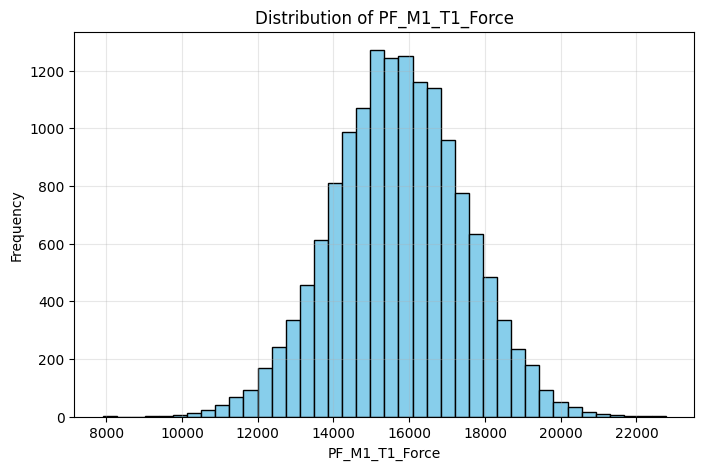

In [13]:
import matplotlib.pyplot as plt

var_name = "PF_M1_T1_Force"
if var_name in obs_dataset.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(obs_dataset[var_name], bins=40, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {var_name}")
    plt.xlabel(var_name)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Variable '{var_name}' not found in the generated data.")

## 11. Final Notes

You have now generated, saved, and processed synthetic causal data, and projected the causal graph to an ADMG, a MAG and a PAG. This prepares your data for advanced causal discovery and analysis tasks. Explore the MAG and the processed data for further insights!